# Simple causal inference question

1. Physical Activity: Does increasing physical activity directly cause a reduction in diabetes risk, or is this effect entirely attributable to confounders?

The **CDC Diabetes Health Indicators Dataset** contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has **diabetes, is pre-diabetic, or healthy**.

In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('/Users/donavanrooi/Documents/Data Science/Datasets/diabetes_012_health_indicators_BRFSS2015.csv')

# The causal pipeline

1. Draw a causal DAG

In [7]:
import matplotlib.pyplot as plt
import dowhy
from dowhy import CausalModel
import tqdm as notebook_tqdm

In [8]:
causal_graph = """
digraph {
  age -> physical_activity;
  age -> bmi;
  age -> diabetes_risk;
  sex -> physical_activity;
  sex -> diabetes_risk;
  sex -> bmi;
  ethnicity -> diabetes_risk;
  ethnicity -> bmi;
  physical_activity -> bmi;
  physical_activity -> diabetes_risk;
  bmi -> diabetes_risk;
  income_level -> physical_activity;
  income_level -> bmi;
  income_level -> diabetes_risk;
  education_level -> physical_activity;
  education_level -> diabetes_risk;
  physical_activity -> cholesterol;
  cholesterol -> diabetes_risk;
  genetics -> physical_activity;
  genetics -> diabetes_risk;
  physical_activity -> BP;
  BMI -> BP;
  BP -> diabetes_risk;
  difficulty_walking -> physical activity;
  mental_health -> physical_activity;
  diet -> diabetes_risk
}
"""

In [9]:
df_model = pd.DataFrame(columns=['age','sex','ethnicity','genetics', 'BP','income_level', 'diet','education_level','physical_activity', 'difficulty_walking','diabetes_risk', 'bmi', 'cholesterol'])
df_model.head()

,age,sex,ethnicity,genetics,BP,income_level,diet,education_level,physical_activity,difficulty_walking,diabetes_risk,bmi,cholesterol


/opt/anaconda3/lib/python3.13/site-packages/dowhy/causal_model.py:581: UserWarning: 4 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(


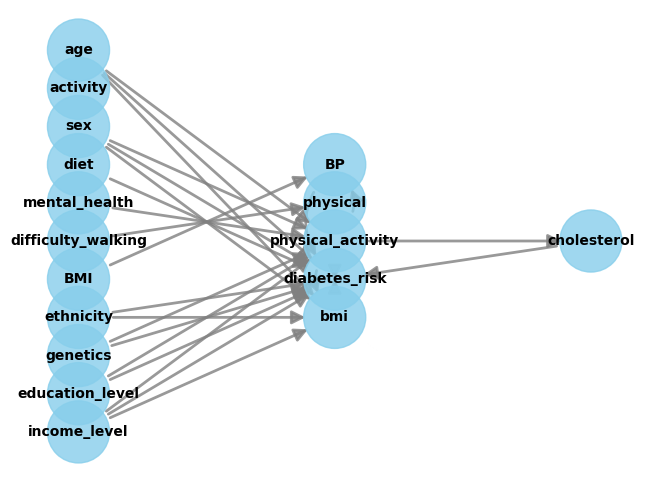

In [10]:
# Define a CausalModel object in DoWhy, indicate treatment & outcome
model= CausalModel(data=df_model, # data columns
        graph=causal_graph, # DAG
        treatment='physical_activity', # cause of interest, X
        outcome='diabetes_risk') # outcome, Y
model.view_model()

# Identification

Identify the causal effect

In [11]:
estimands = model.identify_effect(proceed_when_unidentifiable=True)
print(estimands)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                                     ↪
────────────────────(E[diabetes_risk|income_level,education_level,genetics,sex ↪
d[physical_activity]                                                           ↪

↪       
↪ ,age])
↪       
Estimand assumption 1, Unconfoundedness: If U→{physical_activity} and U→diabetes_risk then P(diabetes_risk|physical_activity,income_level,education_level,genetics,sex,age,U) = P(diabetes_risk|physical_activity,income_level,education_level,genetics,sex,age)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                    -1⎤
 ⎢       d                      ⎛       d                            ⎞  ⎥
E⎢───────────────(diabetesᵣᵢₛₖ)⋅⎜───────────────([physical_activity])⎟  ⎥
 ⎣d[mentalₕₑₐₗₜₕ]               ⎝d[mentalₕₑₐₗₜₕ]                     ⎠  ⎦
Estimand a

**Estimand explanation**: To find the true causal effect of physical activity on diabetes risk, you can directly differentiate the expected value of diabetes risk with respect to physical activity as long as you've blocked all "backdoor paths" (confounders).

My understanding of the estimand outout as it relates to the research question: **If you compare people with different physical activity levels, but make sure they are similar in age, sex, genetics, income, and education, then any remaining difference in diabetes risk is truly caused by physical activity.**

# The Data

In [12]:
df.columns.tolist()

['Diabetes_012',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

The data shows we have variables that may fit the deconfounding set
* HighBP
* HighChol
* BMI
* Veggies, as a proxy for diet
* MentHlth
* DiffWalk
* Sex
* Age
* Education
* Income

* Exporsure: **PhysActvitiy**, binary yes or no
* Outcome: **Diabetes_012**, multiclass diabetic, pre-diabetic, and healthy

In [13]:
df.head(5)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [14]:
# Deconfounding set
# This set must contain age, sex, income, and education because these are the only confounders in the dataset compared to the initial DAG

deconfounding_set = """
digraph {
  Age -> PhysActivity;
  Age -> Diabetes_012;
  Sex -> PhysActivity;
  Sex -> Diabetes_012;
  PhysActivity -> Diabetes_012;
  Income -> PhysActivity;
  Income -> Diabetes_012;
  Education -> PhysActivity;
  Education -> Diabetes_012;
}
"""

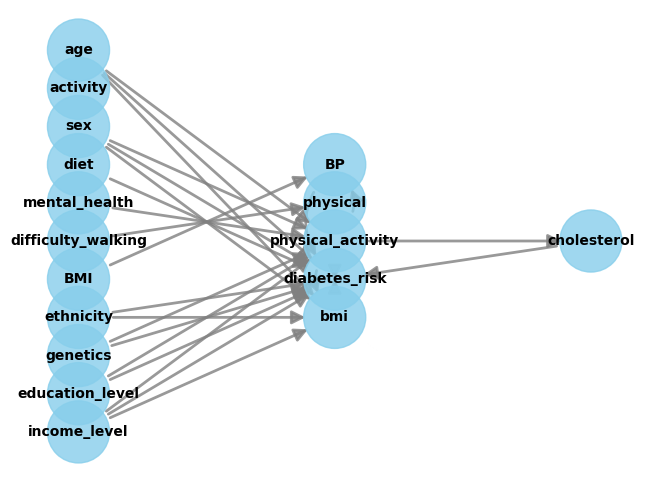

In [15]:
deconfounding_model= CausalModel(data=df, # data columns
        graph=deconfounding_set, # DAG
        treatment='PhysActivity', # exposure
        outcome='Diabetes_012') # outcome
model.view_model()

In [16]:
deconfounding_estimands = deconfounding_model.identify_effect()
print(deconfounding_estimands)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                 
───────────────(E[Diabetes_012|Sex,Age,Education,Income])
d[PhysActivity]                                          
Estimand assumption 1, Unconfoundedness: If U→{PhysActivity} and U→Diabetes_012 then P(Diabetes_012|PhysActivity,Sex,Age,Education,Income,U) = P(Diabetes_012|PhysActivity,Sex,Age,Education,Income)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                                 
───────────────(E[Diabetes_012|Sex,Age,Education,Income])
d[PhysActivity]                                          
Estimand assumption 1, Unconfoundedness: If U→{PhysActivity} and U→Diabetes_012 then P(Diabetes_012|PhysActivity,Sex,Age,Education,Income,U)

Now that we've found adequate measures in our data for all variables in the minimal deconfounding set, and used this data of these measures in our DAG and identification step, we can do estimation.

# Estimation

In [17]:
deconfounding_estimate = deconfounding_model.estimate_effect(deconfounding_estimands,
                                 method_name="backdoor.linear_regression",
                                 effect_modifiers= [],
                                 confidence_intervals=True,
                                 test_significance=True)
print(deconfounding_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                 
───────────────(E[Diabetes_012|Sex,Age,Education,Income])
d[PhysActivity]                                          
Estimand assumption 1, Unconfoundedness: If U→{PhysActivity} and U→Diabetes_012 then P(Diabetes_012|PhysActivity,Sex,Age,Education,Income,U) = P(Diabetes_012|PhysActivity,Sex,Age,Education,Income)

## Realized estimand
b: Diabetes_012~PhysActivity+Sex+Age+Education+Income
Target units: ate

## Estimate
Mean value: -0.12298053445764362
p-value: [0.]
95.0% confidence interval: [[-0.12928182 -0.11667925]]



In [18]:
deconfounding_estimate.interpret()

Increasing the treatment variable(s) [PhysActivity] from 0 to 1 causes an increase of -0.12298053445764362 in the expected value of the outcome [['Diabetes_012']], over the data distribution/population represented by the dataset.


# Conclusion

**People who are physically active have a lower diabetes risk score of about 0.12 points compared to people who are not physically active.**

A negative effect means physical activity pulls people toward 0 (healthy) which is exactly what one would expect clinically. This is a good sign that the model is working correctly.

**This is an average effect across the whole population**

In [88]:
# With statsmodel

In [89]:
import statsmodels.formula.api as smf

In [90]:
reg_model_all = smf.ols(formula='Diabetes_012 ~ PhysActivity + Age + Sex + Income + Education', data = df)
ols_all = reg_model_all.fit()
print('Effect of physical activity: \n coeff: \t', ols_all.params['PhysActivity'], 
      '\n p value: \t', ols_all.pvalues.loc['PhysActivity'], 
     '\n 95% C.I.s: \t', ols_all.conf_int(alpha = 0.05).loc['PhysActivity'].values)

Effect of physical activity: 
 coeff: 	 -0.12298053445760865 
 p value: 	 0.0 
 95% C.I.s: 	 [-0.12928182 -0.11667925]


When using the python library **Statsmodel** We get the exact same results as with the DoWhy estimation